# 08 — Master Comparison

**The portfolio's headline table.** This notebook trains
nothing. It reads each model's
`results/<slug>/metrics.json`, assembles the side-by-side
Pandas summary, and surfaces the cross-model verdict (does
the non-linear model break the linear ceiling?).

Run this AFTER the seven model notebooks (or the seven
`train_*.py` scripts) have populated `results/`.

## 1 — Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
from IPython.display import Image, display

from src.train_utils import RESULTS_DIR
from evaluate_all_results import (
    _load_metrics_files,
    _order_payloads,
    _missing_from_preferred,
    _row_from_payload,
    build_summary_dataframe,
    PREFERRED_ORDER,
)

print(f"RESULTS_DIR = {RESULTS_DIR}")

RESULTS_DIR = /Users/itaysegev/Final_Project_ML/results


## 2 — Discover what's in `results/`

We list every model subdirectory under `results/` and
confirm that the canonical 7-model lineup is present.

In [2]:
payloads = _order_payloads(_load_metrics_files(RESULTS_DIR))
missing = _missing_from_preferred(payloads)

print(f"Found {len(payloads)} model result file(s).")
if missing:
    print(f"Missing from the expected lineup: {missing}")
else:
    print("All 7 expected models present.")

Found 7 model result file(s).
All 7 expected models present.


## 3 — The headline summary table

Each row is one model; columns are accuracy and F1 on the
Baseline and Advanced matrices, plus the Δ between them.
Positive Δ means the engineered culinary features helped.

In [3]:
df = build_summary_dataframe(RESULTS_DIR)

def _style_deltas(v):
    if not isinstance(v, (int, float)) or pd.isna(v):
        return ""
    if v > 0.001:
        return "color: green"
    if v < -0.001:
        return "color: crimson"
    return "color: dimgray"

(
    df.style
      .format({
          "Acc (Baseline)": "{:.4f}",
          "Acc (Advanced)": "{:.4f}",
          "Δ Acc": "{:+.4f}",
          "F1 (Baseline)": "{:.4f}",
          "F1 (Advanced)": "{:.4f}",
          "Δ F1": "{:+.4f}",
      })
      .map(_style_deltas, subset=["Δ Acc", "Δ F1"])
      .set_caption("7-model A/B comparison: Baseline vs Advanced (engineered culinary features)")
)

,Model,Acc (Baseline),Acc (Advanced),Δ Acc,F1 (Baseline),F1 (Advanced),Δ F1
0,Perceptron,0.5495,0.5457,-0.0038,0.5726,0.5696,-0.0030
1,Logistic Regression,0.5984,0.6030,+0.0047,0.6428,0.6435,+0.0008
2,AdaBoost (n=100),0.5948,0.5967,+0.0019,0.6621,0.6518,-0.0103
3,PCA(0.90) + KNN,0.5147,0.5133,-0.0014,0.5565,0.5578,+0.0013
4,PCA(0.90) + KNN (Improved),0.5602,0.5630,+0.0027,0.5820,0.5904,+0.0084
5,Random Forest,0.6041,0.6178,+0.0137,0.6565,0.6708,+0.0143
6,"MLP (128, 64) + early stopping",0.5973,0.6066,+0.0093,0.6668,0.6477,-0.0192


## 4 — Cross-model verdict (linear baseline vs non-linear)

LR is the calibrated linear baseline. Random Forest and
MLP are the non-linear contenders. The "meaningful gain"
threshold is 1 percentage point on either Acc or F1.

In [4]:
MEANINGFUL = 0.01
by_name = {p["model_name"]: p for p in payloads}
lr  = by_name.get("LogisticRegression")
rf  = by_name.get("RandomForest")
mlp = by_name.get("MLP (128,64)")
assert lr is not None, "LogisticRegression metrics missing"

def _classify(model_name, p):
    lr_a = lr["datasets"]["Advanced"]
    ad = p["datasets"]["Advanced"]
    d_acc = ad["accuracy"] - lr_a["accuracy"]
    d_f1 = ad["f1"] - lr_a["f1"]
    if d_acc >= MEANINGFUL and d_f1 >= MEANINGFUL:
        verdict = "✅ BREAKS the linear ceiling on both metrics"
    elif d_acc >= MEANINGFUL or d_f1 >= MEANINGFUL:
        verdict = "🟡 PARTIAL gain (one metric only)"
    elif d_acc <= -MEANINGFUL or d_f1 <= -MEANINGFUL:
        verdict = "❌ UNDERPERFORMS the linear baseline"
    else:
        verdict = "⚖️ PLATEAUS within noise of LR"
    return {
        "Model": model_name,
        "Acc (Advanced)": ad["accuracy"],
        "Δ vs LR (Acc)": d_acc,
        "F1 (Advanced)": ad["f1"],
        "Δ vs LR (F1)": d_f1,
        "Verdict": verdict,
    }

verdict_rows = []
if rf is not None: verdict_rows.append(_classify("RandomForest", rf))
if mlp is not None: verdict_rows.append(_classify("MLP (128,64)", mlp))
verdict_df = pd.DataFrame(verdict_rows).set_index("Model")

display(verdict_df.style.format({
    "Acc (Advanced)": "{:.4f}",
    "F1 (Advanced)": "{:.4f}",
    "Δ vs LR (Acc)": "{:+.4f}",
    "Δ vs LR (F1)": "{:+.4f}",
}))

,Acc (Advanced),Δ vs LR (Acc),F1 (Advanced),Δ vs LR (F1),Verdict
Model,,,,,
RandomForest,0.6178,+0.0148,0.6708,+0.0273,✅ BREAKS the linear ceiling on both metrics
"MLP (128,64)",0.6066,+0.0036,0.6477,+0.0042,⚖️ PLATEAUS within noise of LR


## 5 — The PCA + KNN before/after story

The most diagnostic-driven result in the project: dropping
the four nutrition columns before PCA expands the retained
search space from 1 component to ~200 components and lifts
KNN accuracy by ~5 percentage points. README §4 Lesson #5.

In [5]:
orig = by_name.get("PCA(0.90) + KNN")
improved = by_name.get("PCA(0.90) + KNN (Improved)")

if orig is not None and improved is not None:
    pca_orig = orig["extras"]["pca_components_retained"]
    pca_imp  = improved["extras"]["pca_components_retained"]

    cmp = pd.DataFrame({
        "Original — components": pca_orig,
        "Improved — components": pca_imp,
        "Original — Acc": {ds: orig["datasets"][ds]["accuracy"] for ds in pca_orig},
        "Improved — Acc": {ds: improved["datasets"][ds]["accuracy"] for ds in pca_imp},
        "Δ Acc": {ds: improved["datasets"][ds]["accuracy"] - orig["datasets"][ds]["accuracy"] for ds in pca_imp},
    })
    display(cmp.style.format({
        "Original — Acc": "{:.4f}",
        "Improved — Acc": "{:.4f}",
        "Δ Acc": "{:+.4f}",
    }))

,Original — components,Improved — components,Original — Acc,Improved — Acc,Δ Acc
Baseline,1,203,0.5147,0.5602,+0.0455
Advanced,1,182,0.5133,0.5630,+0.0497


## 6 — Embedded plot gallery

Each model's headline plot, side-by-side. Images come from
`results/<slug>/`, so they reflect whatever was last
written by the model's notebook (or the matching
`train_<model>.py` script).

Logistic Regression — Confusion Matrix


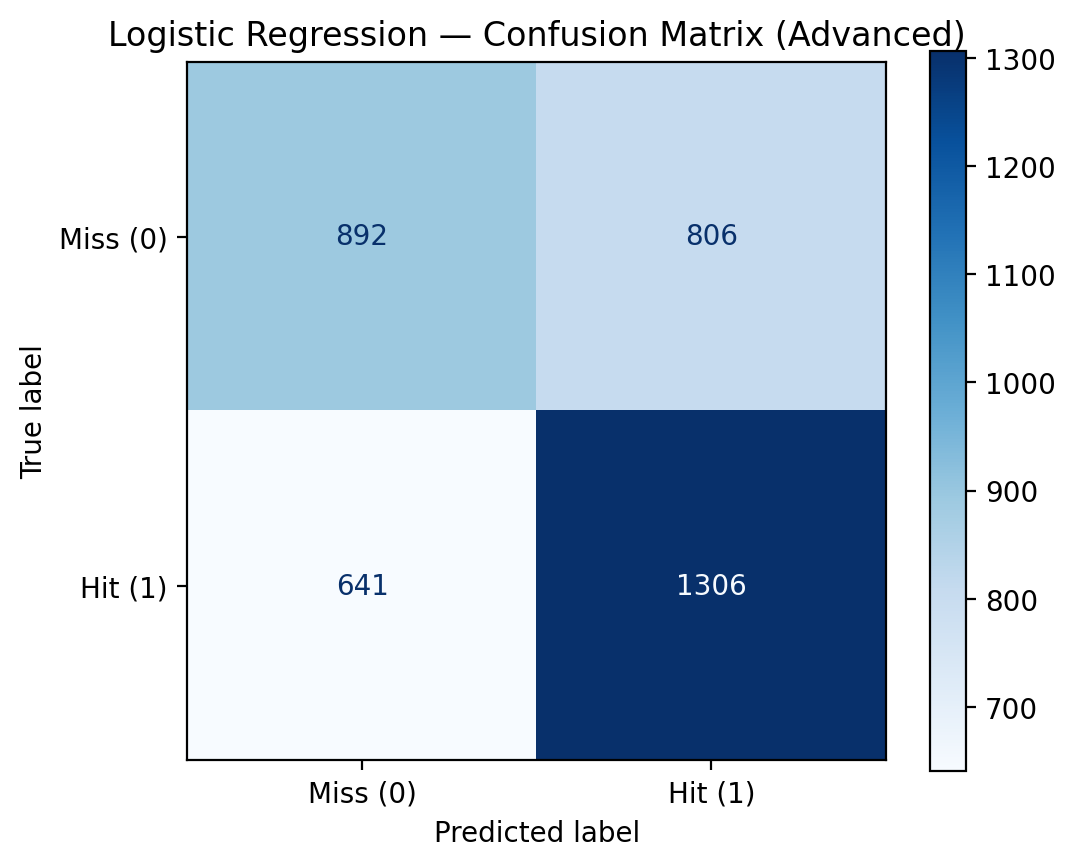

Logistic Regression — ROC Curve


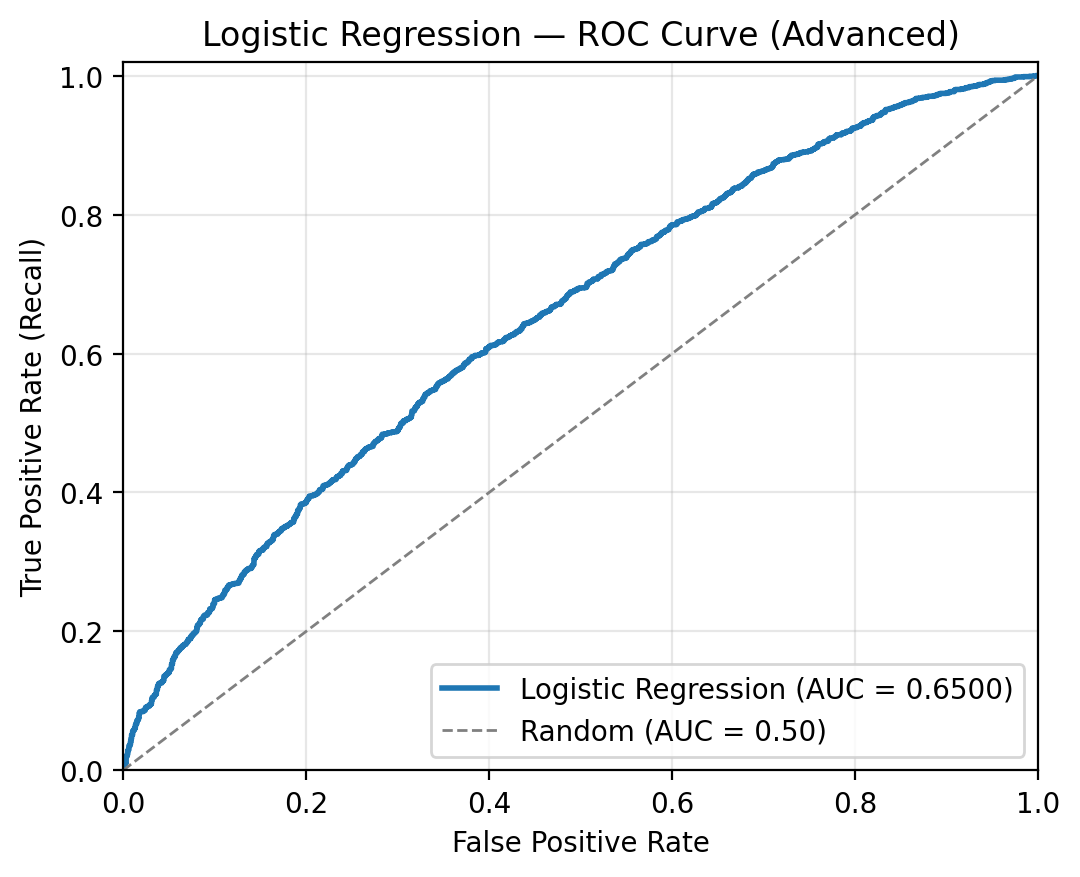

Random Forest — Feature Importance


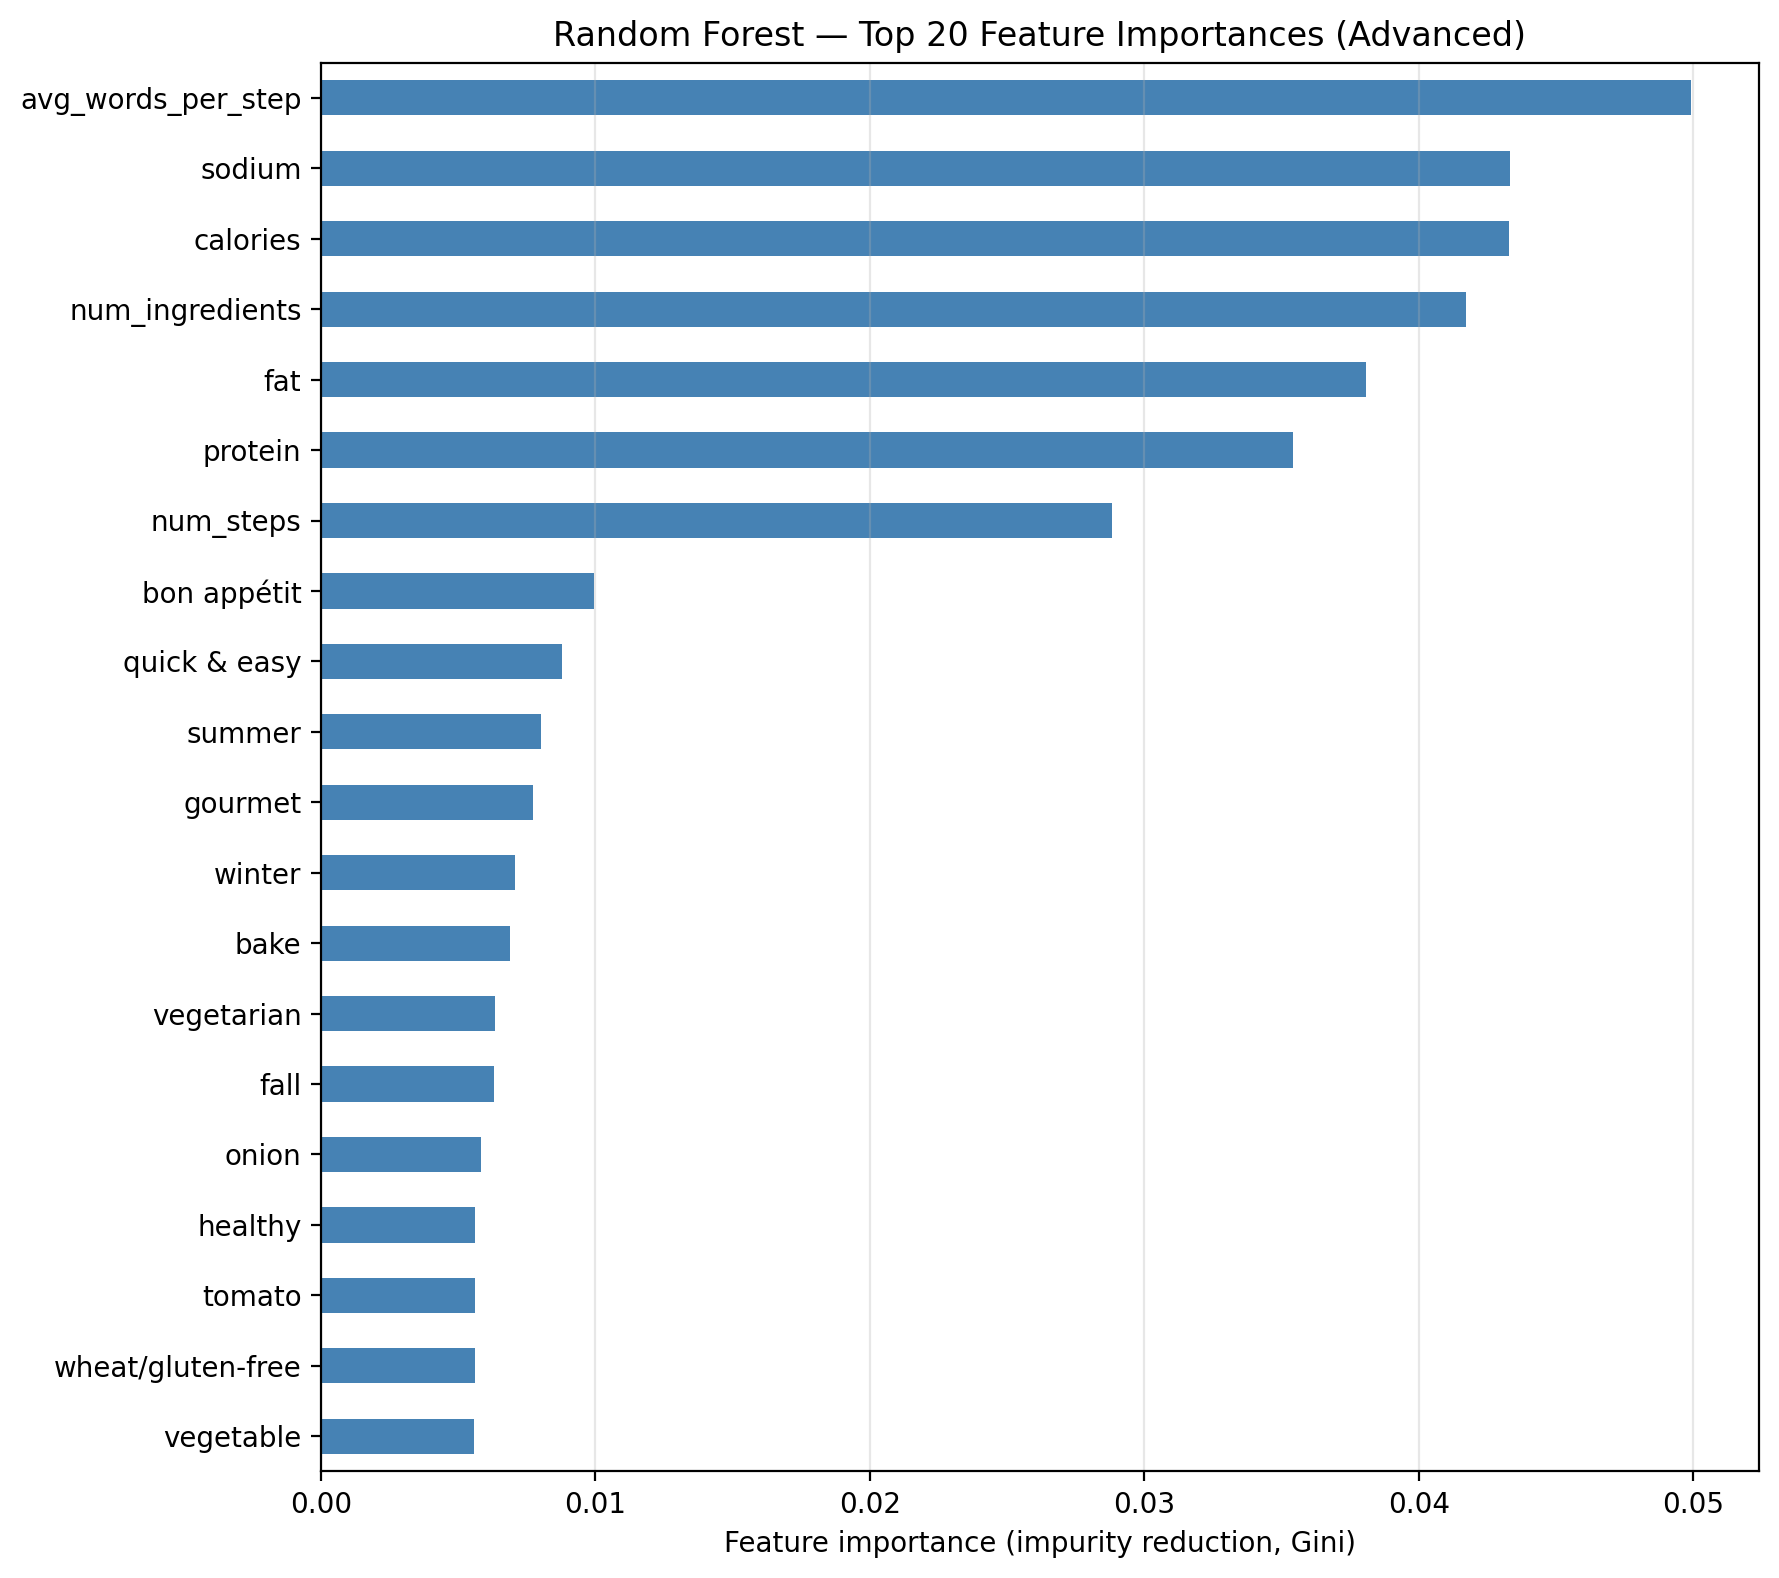

MLP — Loss Curve + Validation Overlay


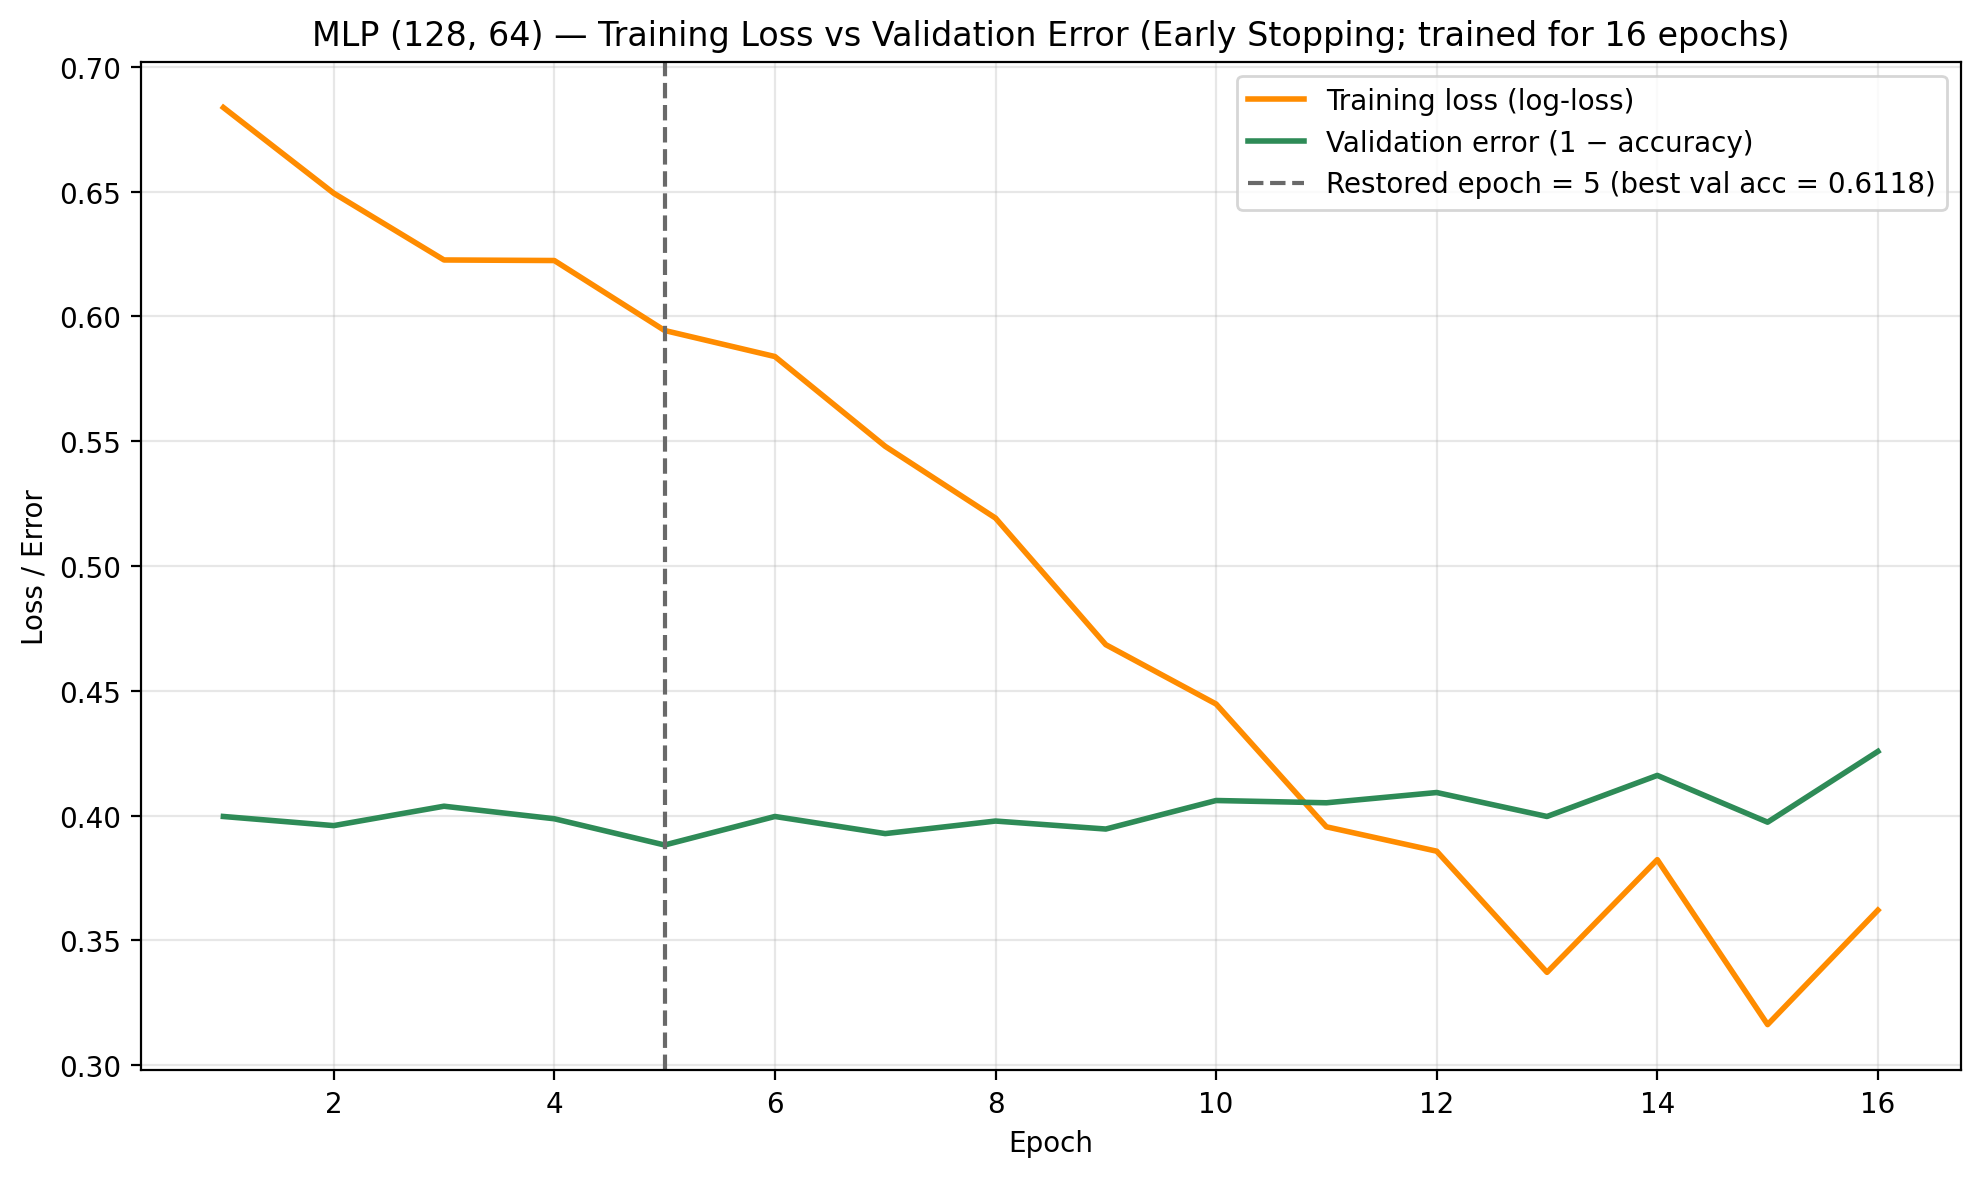

In [6]:
plot_gallery = [
    ("Logistic Regression — Confusion Matrix", "logistic_regression/confusion_matrix.png"),
    ("Logistic Regression — ROC Curve",        "logistic_regression/roc_curve.png"),
    ("Random Forest — Feature Importance",     "random_forest/feature_importance.png"),
    ("MLP — Loss Curve + Validation Overlay",  "mlp/loss_curve.png"),
]

for caption, rel_path in plot_gallery:
    full_path = RESULTS_DIR / rel_path
    if full_path.exists():
        print(caption)
        display(Image(str(full_path)))
    else:
        print(f"[missing] {caption} ({rel_path})")

## 7 — Final verdict (one-liner per model class)

- **Linear interpretable champion:** Logistic Regression
  (calibrated probabilities, signed coefficients).
- **Predictive champion:** Random Forest — breaks the
  linear ceiling +1.48% Acc / +2.73% F1.
- **MLP:** matches LR within noise after early stopping;
  capacity ≠ accuracy on this dataset.
- **KNN (cautionary tale → algorithmic fix):** the
  diagnostic-driven `Improved` variant lifts accuracy +5
  pp by dropping outlier-dominated columns before PCA.

See `README.md` for the full narrative.